In [4]:
import sys
sys.path.insert(0, "../../processing/")

In [5]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.signal import butter, filtfilt

import scipy.signal as signal

import cartopy

import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

## 1- FILTERING INERTIAL OSCILLATIONS

In [6]:
def butter_highpass_filter(data, cutoff, fs, order=5):
    """
    Aplica un filtro Butterworth de paso alto.
   
        Args:
        - data: Array de datos a filtrar.
        - cutoff: Frecuencia de corte del filtro.
        - fs: Frecuencia de muestreo de los datos.
        - order: Orden del filtro.
    
        Returns:
        - y: Datos filtrados.
    
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

In [15]:
# filedir = '/home/everger/Onedrive/SWOT/drifters/L0_svpb/'
#filedir = 'C:/Users/Usuario/OneDrive - Universitat de les Illes Balears/SWOT/drifters/L0_svpb/'
filedir = '../../../../../data/drifters/L0/SVP-B/'

In [16]:
url_01 = filedir + "OSMC_flattened_6204605.nc"

In [17]:
ds00_a = xr.open_dataset(url_01)

# Rename variables (for coherence with the other drifters)
ds00_b = ds00_a.rename({'longitude': 'LON', 'latitude': 'LAT'})

ds00 = ds00_b.to_dataframe().set_index(['time']).to_xarray()

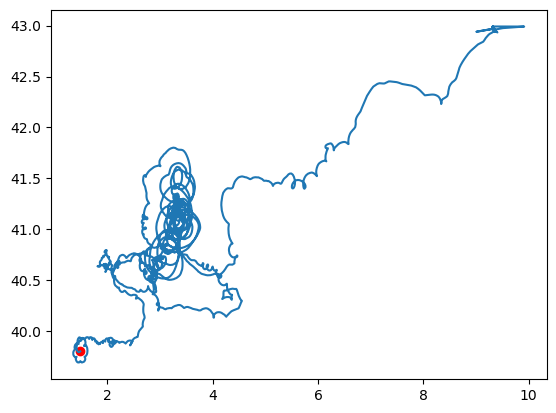

In [18]:
plt.plot(ds00.LON, ds00.LAT)
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')

In [19]:
cuttof_frequency = 1/36 # 31 hores
fs = 1 # mostreig cada hora

In [21]:
lon_filtered = butter_highpass_filter(ds00.LON, cuttof_frequency, fs)
lat_filtered = butter_highpass_filter(ds00.LAT, cuttof_frequency, fs)

prova:

In [22]:
df00 = ds00.to_dataframe()
df00.insert(6, "lon_filtered", lon_filtered, True)
df00.insert(7, "lat_filtered", lat_filtered, True)
df00

,platform_code,country,LAT,LON,sst,slp,lon_filtered,lat_filtered
time,,,,,,,,
2023-04-26 13:49:00,6204605,UNKNOWN,39.80040,1.48620,35.93,1016.5,1.488157,39.799217
2023-04-26 14:00:00,6204605,UNKNOWN,39.80040,1.48620,20.99,1016.5,1.482272,39.803586
2023-04-26 15:00:00,6204605,UNKNOWN,39.79680,1.47940,19.73,1015.9,1.476399,39.807945
2023-04-26 16:00:00,6204605,UNKNOWN,39.79380,1.47140,19.51,1015.8,1.470618,39.812292
2023-04-26 18:00:00,6204605,UNKNOWN,39.79360,1.45020,18.49,1015.3,1.465004,39.816628
...,...,...,...,...,...,...,...,...
2023-11-10 08:04:00,6204605,UNITED STATES,42.96711,9.30913,17.97,1020.2,9.295695,42.972277
2023-11-10 09:04:00,6204605,UNITED STATES,42.99135,9.31708,19.06,1020.1,9.295100,42.972117
2023-11-10 10:04:00,6204605,UNITED STATES,42.96711,9.30913,18.74,1020.0,9.294727,42.971963


In [10]:
DS00 = xr.Dataset.from_dataframe(df00)

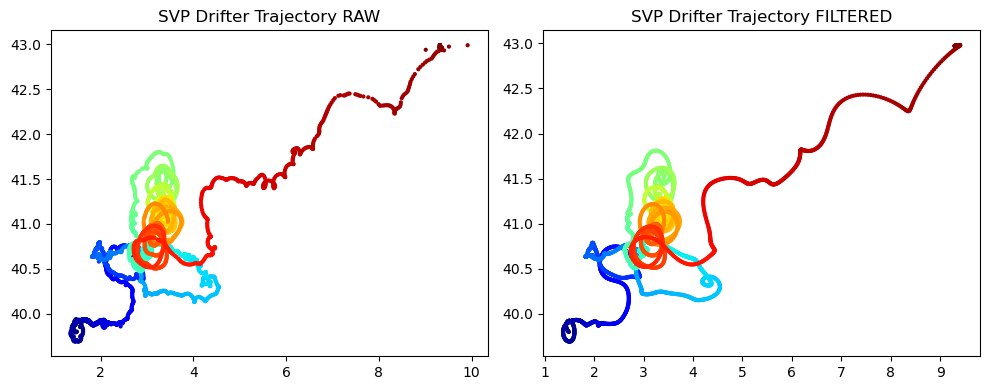

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))  # Adjust figsize as needed

# Plot the first scatter plot on the first subplot (ax1)
sc1 = ax1.scatter(DS00.LON, DS00.LAT, 4, c=ds00.time, cmap='jet')
ax1.set_title('SVP Drifter Trajectory RAW')

# Plot the second scatter plot on the second subplot (ax2)
sc2 = ax2.scatter(DS00.lon_filtered, DS00.lat_filtered, 4, c=DS00.time, cmap='jet')
ax2.set_title('SVP Drifter Trajectory FILTERED')

# Adjust layout and display the plots
plt.tight_layout()

#plt.savefig('drifters_filtering.png',dpi=300)

# 2. Processing:

In [12]:
# Checking time interval:

print(DS00.time[1].data)
print(DS00.time[2].data)

# --> Should be: 
# 10 mins freq. for CARTHE
# 5 mins HEREON
# 1h SVP-B

2023-04-26T14:00:00.000000000
2023-04-26T15:00:00.000000000


## 2.1. Identifying large time gaps (to kill drifter traj trash)

In [13]:
# elif drifter_type == 'S':
#     url_vars = "trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]"
#     temp_res = 3600.
# extret de codi laura, si es fa per tots tipus de drifters anar a recuperar aquesta part

temp_res = 3600.

In [14]:
diff_time_thres = 3600*3 # [s]

In [15]:
dt_drif = DS00.time.diff("time").dt.seconds #ds00c

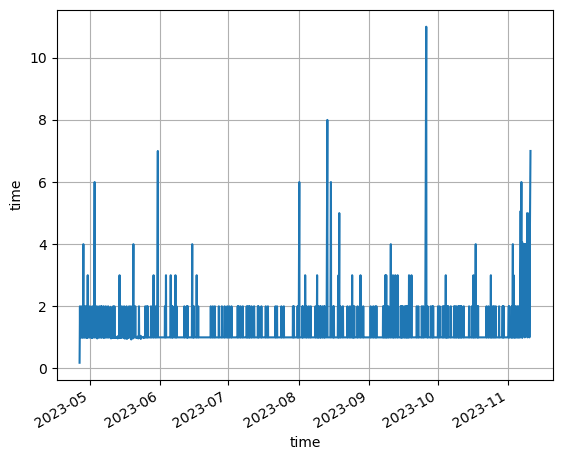

In [16]:
# Plotting diff in hours:
# ((ds00.time.diff("time") / 1.e9) / 3600.).plot()
(DS00.time.diff("time")/ np.timedelta64(1, 'h') ).plot()
plt.grid()


### Subselecting between 14 h time diff and 11h gaps:

In [17]:
inds_dt01 = 15. * 60 * 60 # [s]

inds_trash_p1 = np.where(dt_drif >= inds_dt01)[0]
print(inds_trash_p1)
print(inds_trash_p1.size)

[]
0


In [18]:
inds_dt02 = 11. * 60 * 60 # [s]
inds_trash_p2 = np.where(dt_drif == inds_dt02)[0]
print(inds_trash_p2)
print(inds_trash_p2.size)

[3434]
1


In [19]:
# ds01 = ds00.where((ds00.time>ds00.time[inds_trash_p1[0]+2]) & (ds00.time<ds00.time[inds_trash_p2[0]-2]), drop=True) # to improve , comentat perquè inds_trash_p1 sortia buit
DS01 = DS00.where((DS00.time<DS00.time[inds_trash_p2[0]-2]), drop=True) # to improve 

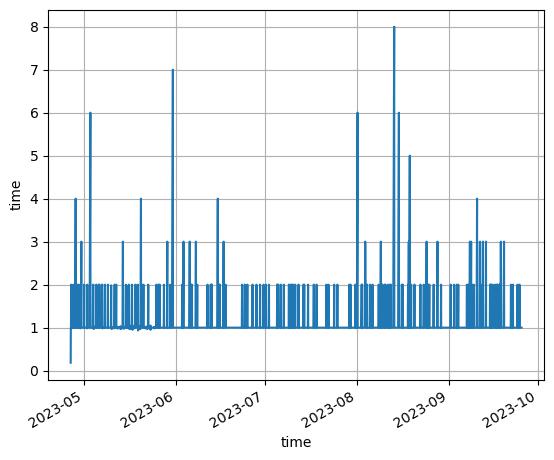

In [20]:
# Plotting diff in hours:
(DS01.time.diff("time")/ np.timedelta64(1, 'h') ).plot()
plt.grid()


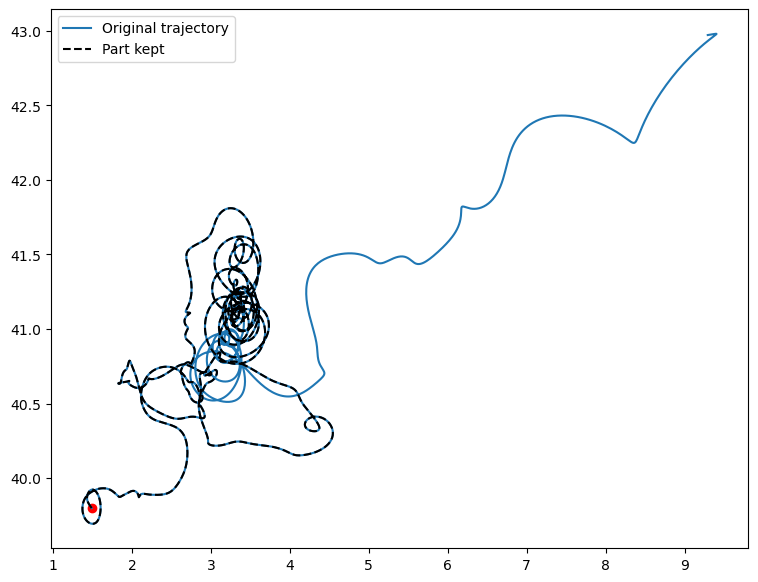

In [21]:
plt.figure(figsize=(9,7))
plt.plot(DS00.lon_filtered, DS00.lat_filtered, label='Original trajectory')
plt.scatter(DS00.lon_filtered[0], DS00.lat_filtered[0], c='r')
plt.plot(DS01.lon_filtered, DS01.lat_filtered, '--k', label='Part kept')
plt.legend()

## 2.2. Resampling to regular 10 mins. intervals:
(constant 10 mins and "o'clock" times)

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.
***  Not needed for the SVP, LON and LAT are already variables

In [22]:
#ds01 = ds01.reset_coords("LON")
#ds01 = ds01.reset_coords("LAT")

### 2.2.2. Drop string variables

In [23]:
DS01

<xarray.Dataset>
Dimensions:        (time: 3432)
Coordinates:
  * time           (time) datetime64[ns] 2023-04-26T13:49:00 ... 2023-09-25T1...
Data variables:
    platform_code  (time) object '6204605' '6204605' ... '6204605' '6204605'
    country        (time) object 'UNKNOWN' 'UNKNOWN' ... 'UNITED STATES'
    LAT            (time) float64 39.8 39.8 39.8 39.79 ... 41.09 41.08 41.07
    LON            (time) float64 1.486 1.486 1.479 1.471 ... 3.425 3.434 3.442
    sst            (time) float64 35.93 20.99 19.73 19.51 ... 25.08 25.08 25.12
    slp            (time) float64 1.016e+03 1.016e+03 ... 1.035e+03 1.035e+03
    lon_filtered   (time) float64 1.488 1.482 1.476 1.471 ... 3.41 3.414 3.416
    lat_filtered   (time) float64 39.8 39.8 39.81 39.81 ... 41.08 41.06 41.05

In [24]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
DS01 = DS01.drop_vars("platform_code")
DS01 = DS01.drop_vars("country") 

#ds01 = ds01.drop_vars("DEPTH") # trajectory variable unnecessary, check with Lara --> not better attrubte?

### 2.2.3. Resampling:

In [25]:
DS02 = DS01.resample(time="1H").interpolate("linear") # xarray resample works very differently from pandas

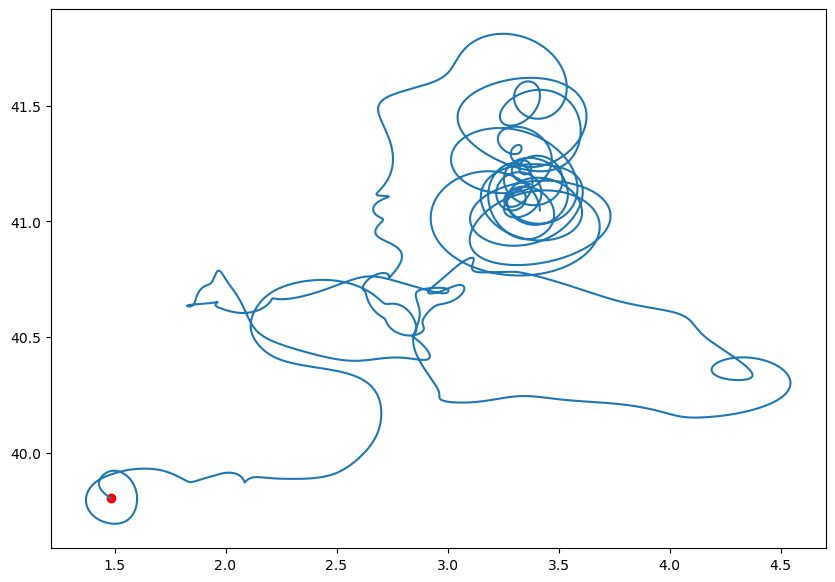

In [26]:
plt.figure(figsize=(10,7))
# plt.plot(DS02.LON, DS02.LAT) #PER COMPARAR AMB UNFILTERED
plt.plot(DS02.lon_filtered, DS02.lat_filtered) 

# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(DS02.lon_filtered[1], DS02.lat_filtered[1], c='r')

## 2.3. Calculate forward and backward velocities

In [28]:
DS02

<xarray.Dataset>
Dimensions:       (time: 3647)
Coordinates:
  * time          (time) datetime64[ns] 2023-04-26T13:00:00 ... 2023-09-25T11...
Data variables:
    LAT           (time) float64 nan 39.8 39.8 39.79 ... 41.11 41.09 41.08 41.07
    LON           (time) float64 nan 1.486 1.479 1.471 ... 3.425 3.434 3.442
    sst           (time) float64 nan 20.99 19.73 19.51 ... 25.08 25.08 25.12
    slp           (time) float64 nan 1.016e+03 1.016e+03 ... 1.035e+03 1.035e+03
    lon_filtered  (time) float64 nan 1.482 1.476 1.471 ... 3.41 3.414 3.416
    lat_filtered  (time) float64 nan 39.8 39.81 39.81 ... 41.1 41.08 41.06 41.05

In [29]:
# Calculate forward and backward finite differences
speed, ufor, vfor = latlon2uv_dir(DS02.lat_filtered, DS02.lon_filtered, temp_res, 'forward')
_, uback, vback = latlon2uv_dir(DS02.lat_filtered, DS02.lon_filtered, temp_res, 'back')

In [30]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

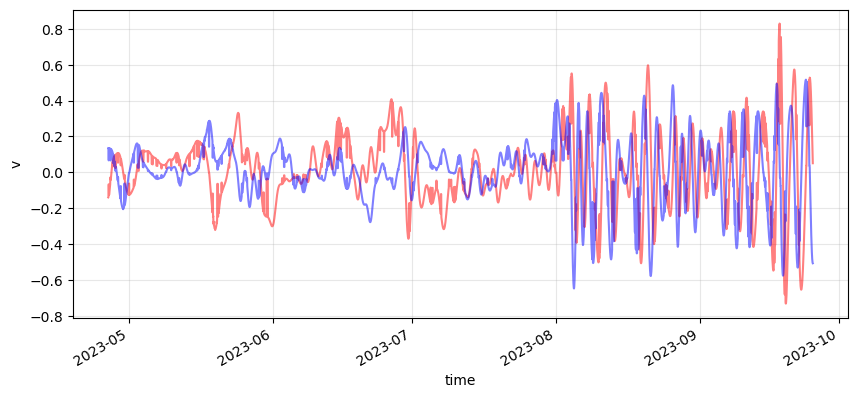

In [31]:
# Check values for spikes
plt.figure(figsize=(10,4))
u.plot(alpha = 0.5, color = "red");
v.plot(alpha = 0.5, color = "blue");
plt.grid(alpha=0.3)

In [32]:
# Add variables to the dataset
DS02 = DS02.assign(U=u)
DS02 = DS02.assign(V=v)
print(list(DS02.keys()))

['LAT', 'LON', 'sst', 'slp', 'lon_filtered', 'lat_filtered', 'U', 'V']


In [33]:
DS02.U.values

array([        nan, -0.13934534, -0.13716537, ...,  0.09563811,
        0.05086892,         nan])

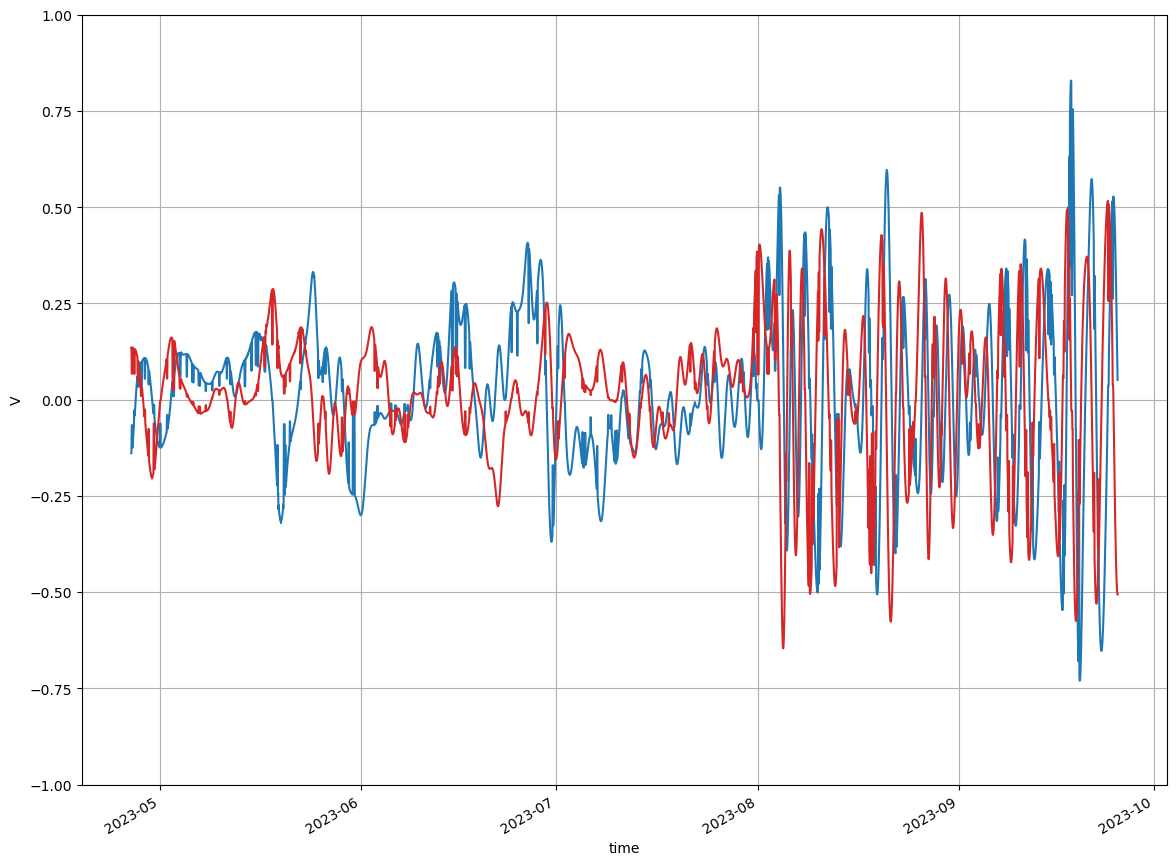

In [34]:
DS02.U.plot(figsize=(14,10))
DS02.V.plot(c='C3')
plt.ylim([-1, 1])
plt.grid()

## 2.4. Spike cleaning:



Cleaning spikes now based on velocity thresholds(absolute velocity (speed))

We will look velocity’s module magnitude to identify spikes due to spurious data







In [35]:
abs_vel = (DS02.U**2 + DS02.V**2)**0.5

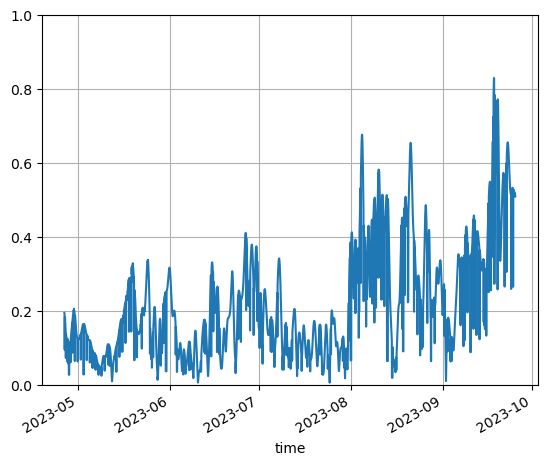

In [36]:
abs_vel.plot()
plt.ylim([0,1])
plt.grid()

### 2.4.1. Large spikes removal

Based on above plot we choose 0.8 m/s.

To improve:
- big spike cleaning with lon and lat thres. before resmpling
- do a moving vel. thres.
- would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

In [37]:
vel_thres = 0.8 # m/s # 1.5 se cuelan spikes # 1. also lowe limits pikes se cuela

In [38]:
DS03 = DS02.where(abs_vel < vel_thres)

In [39]:
abs_vel_thres = (DS03.U**2 + DS03.V**2)**0.5

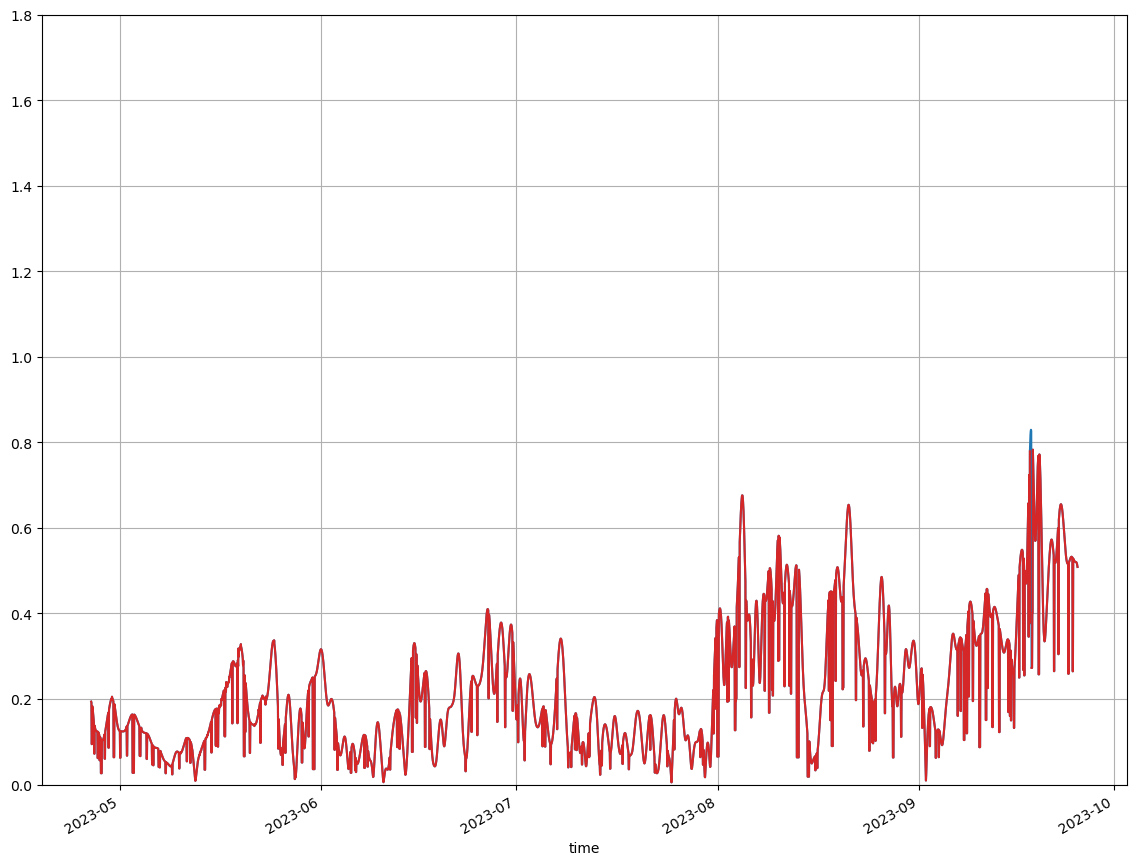

In [40]:
abs_vel.plot(figsize=(14,10))
abs_vel_thres.plot(c='C3')
plt.ylim([0,1.8])
plt.grid()

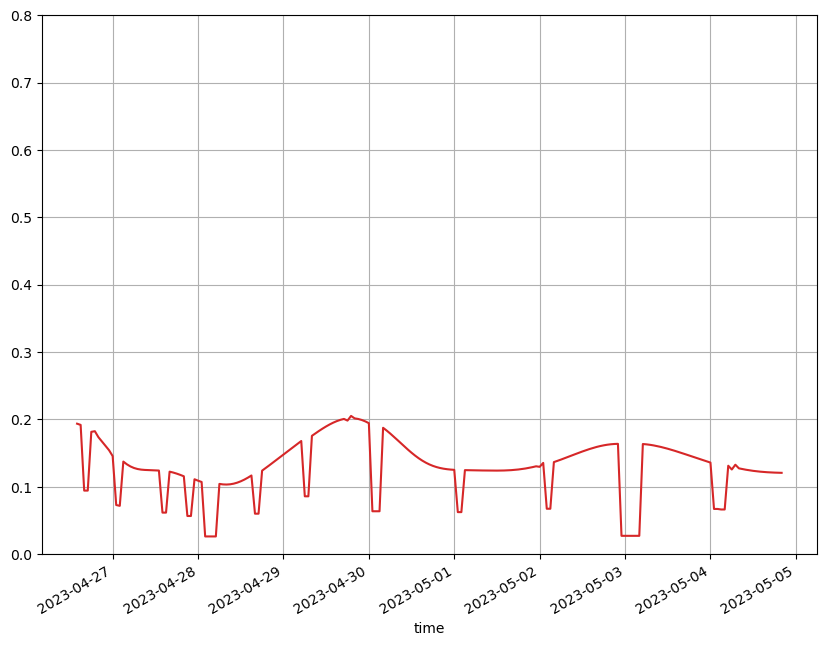

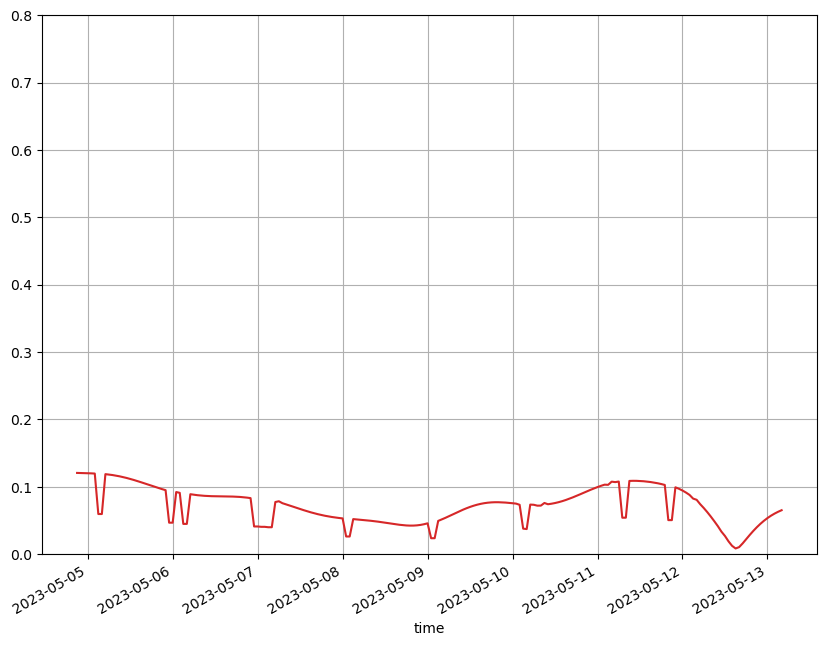

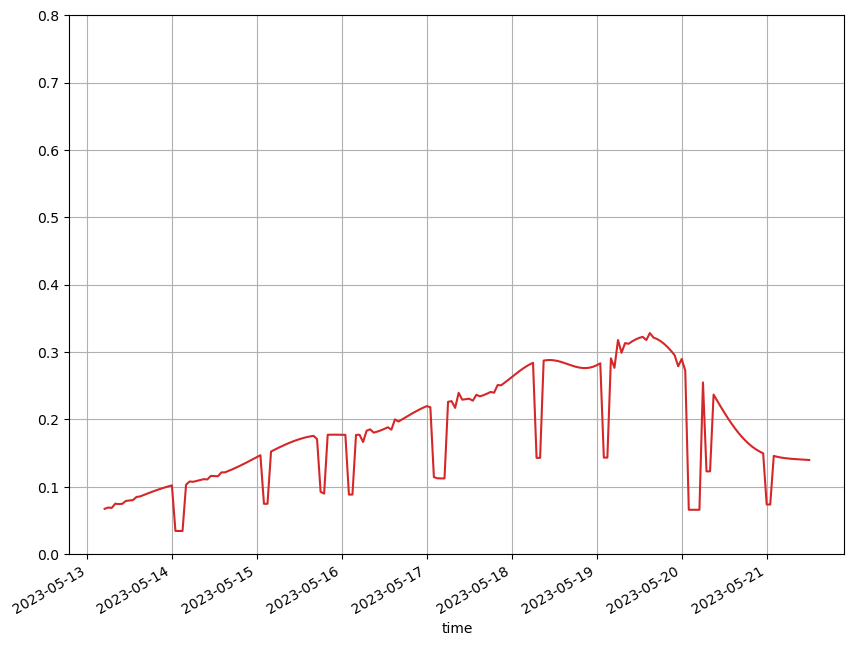

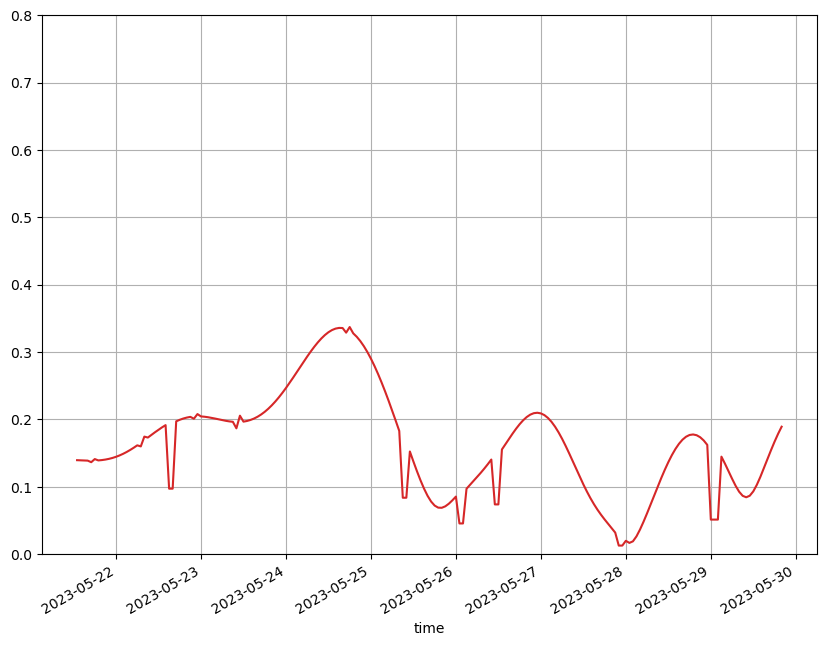

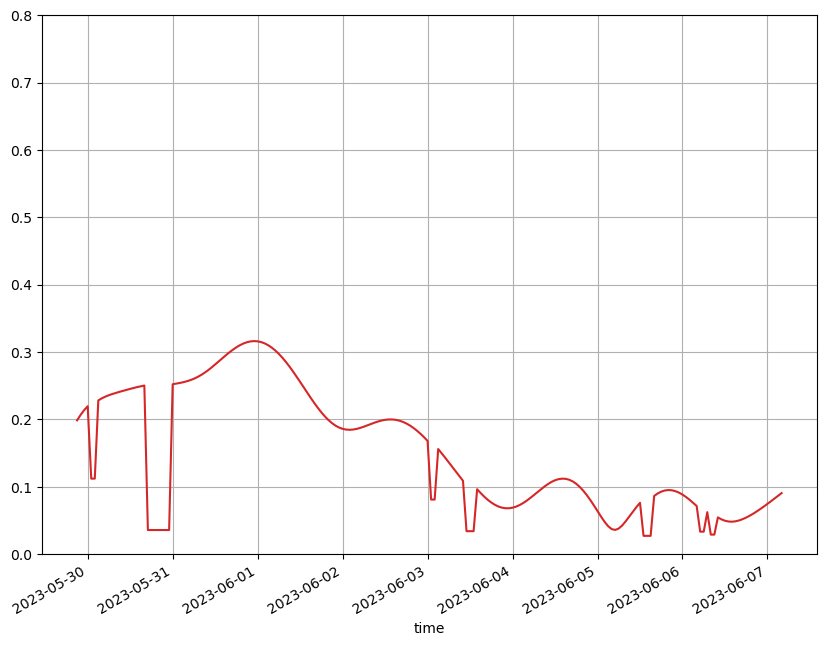

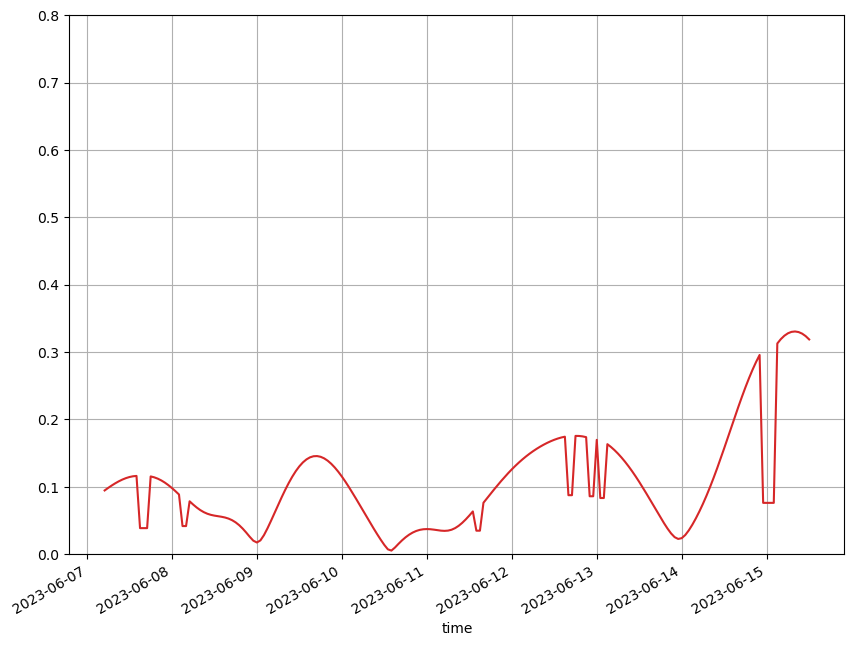

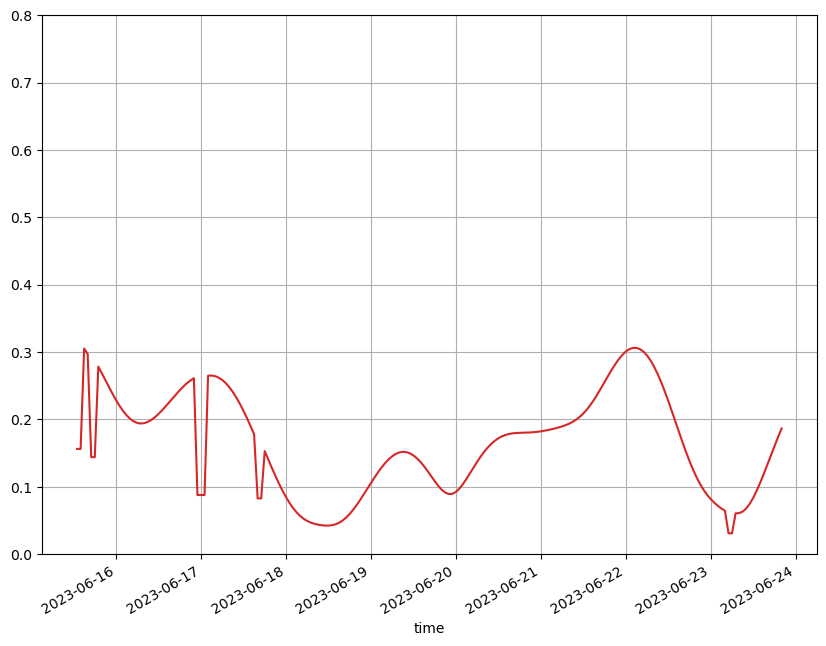

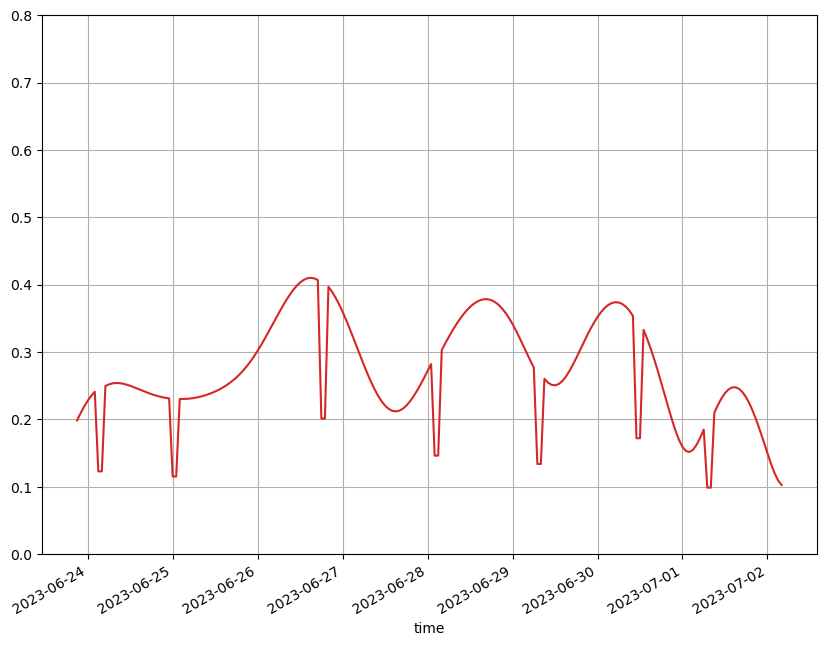

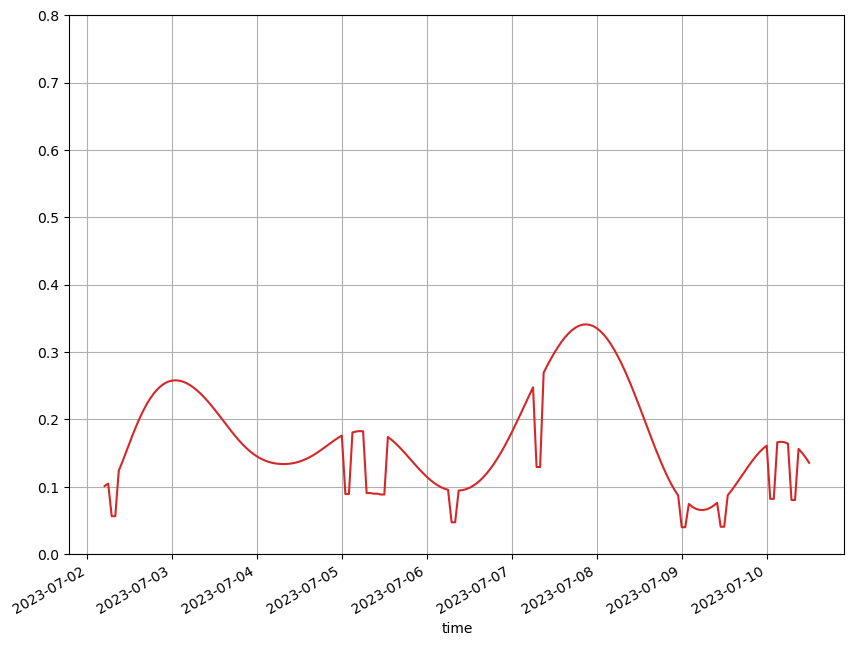

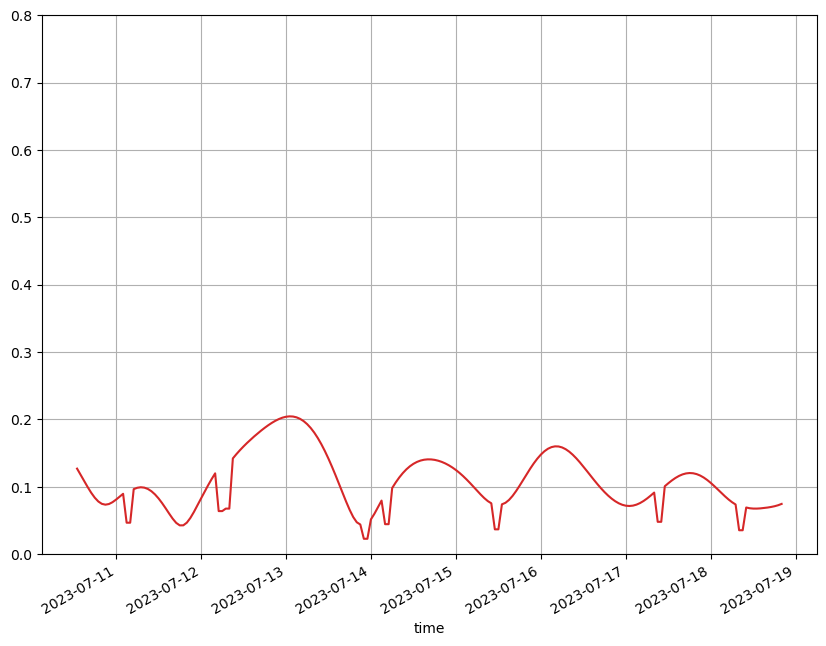

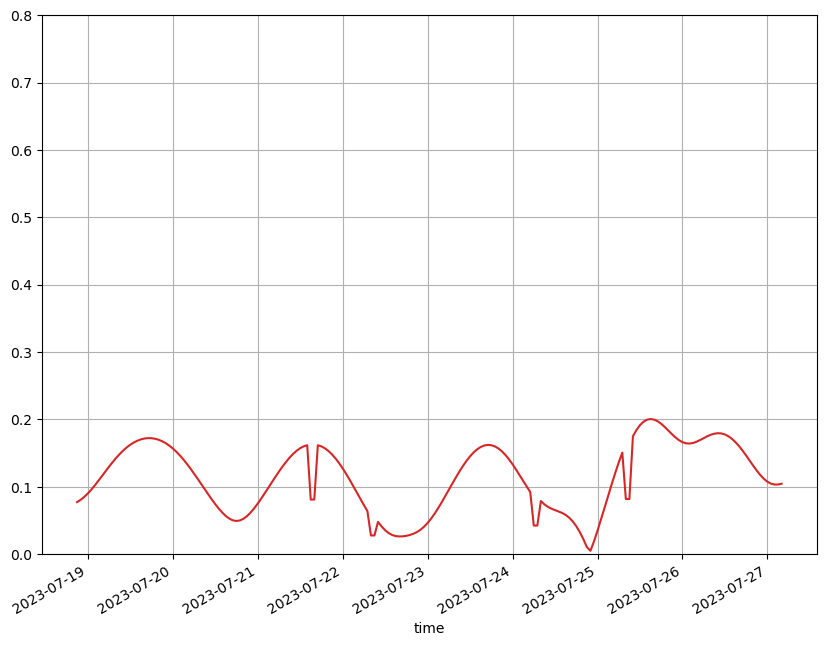

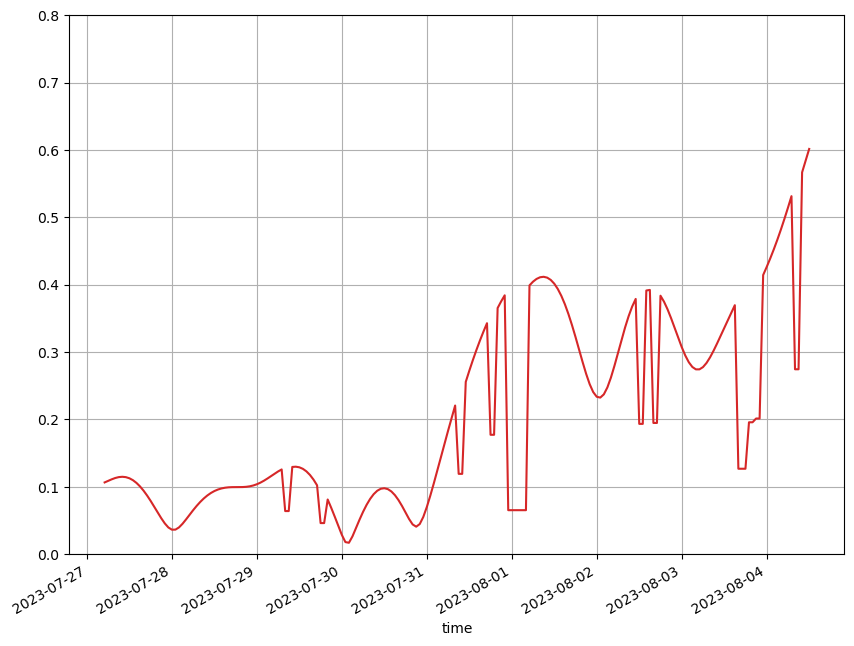

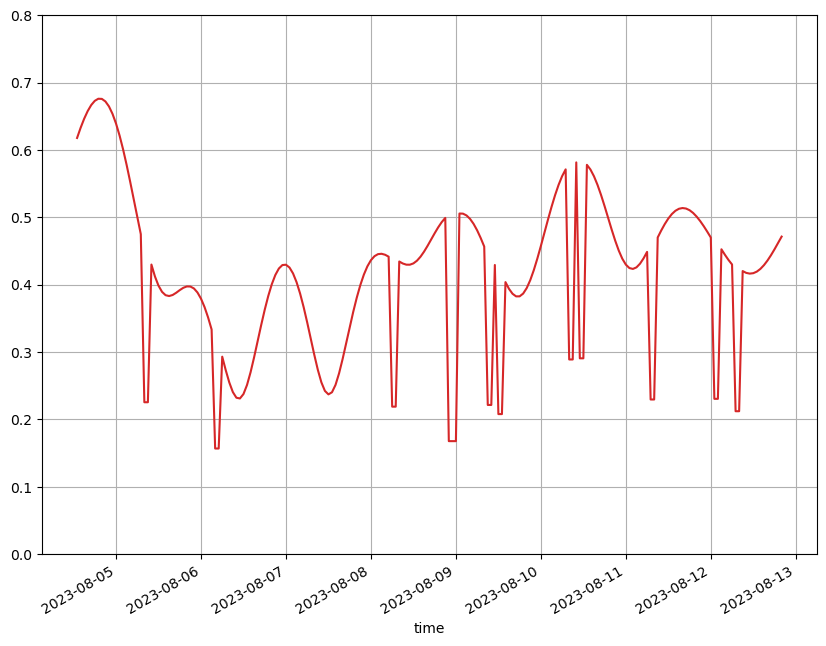

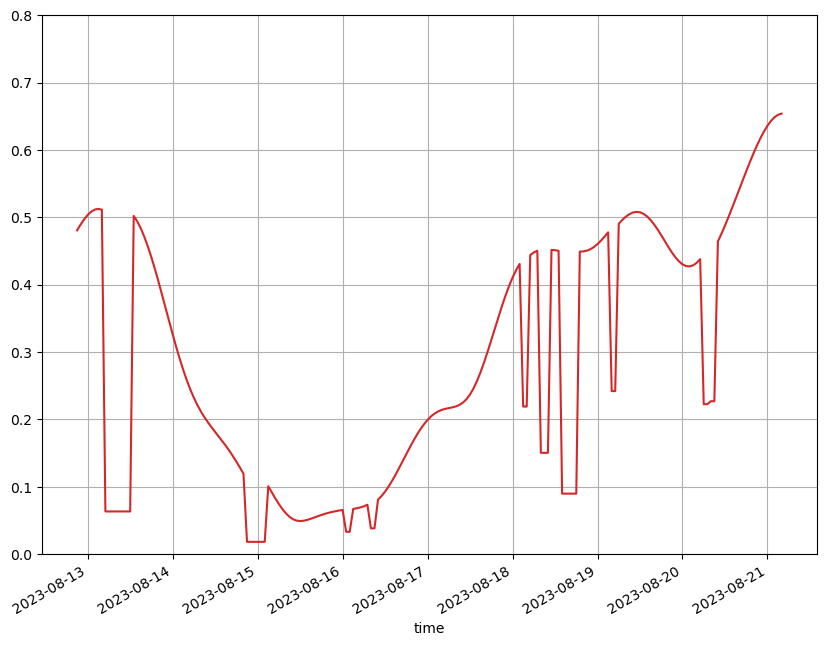

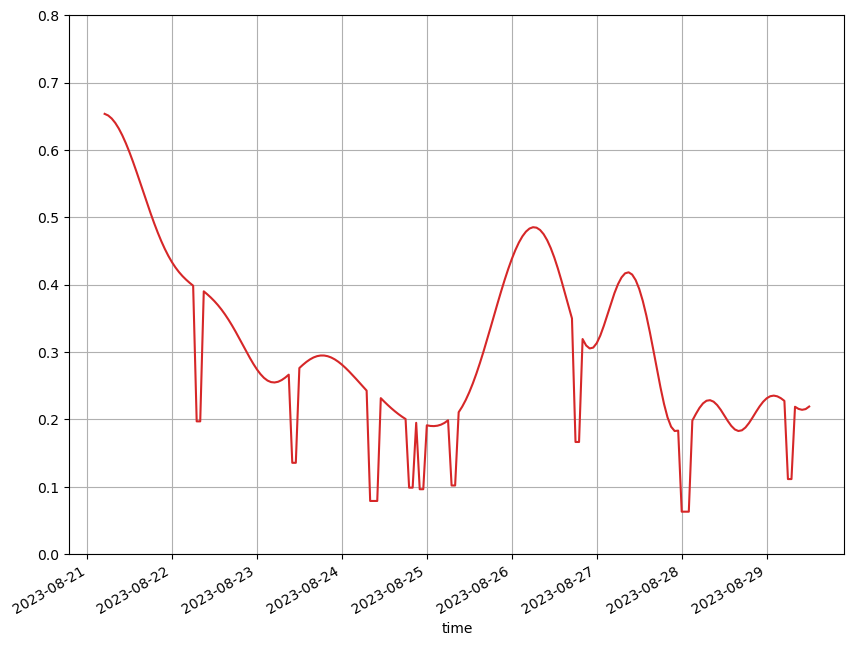

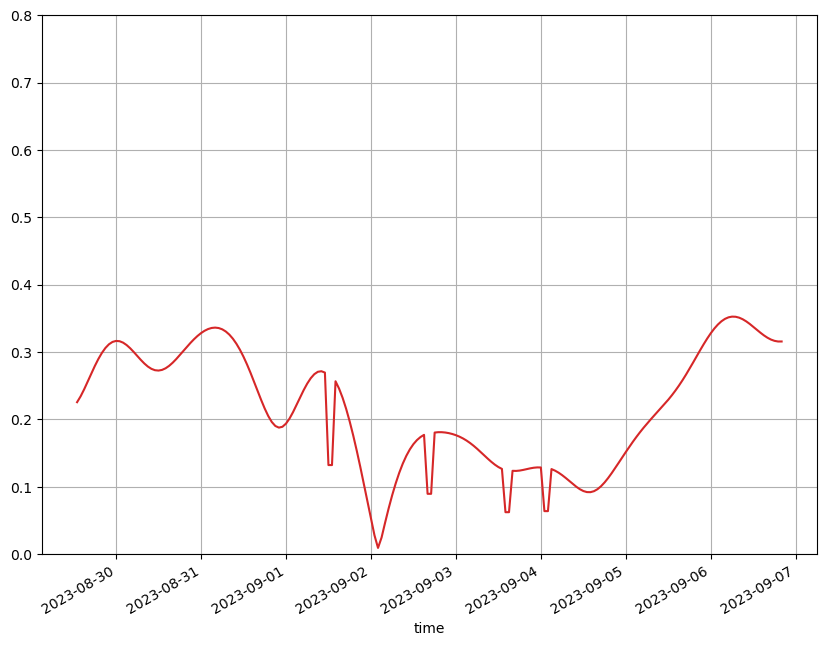

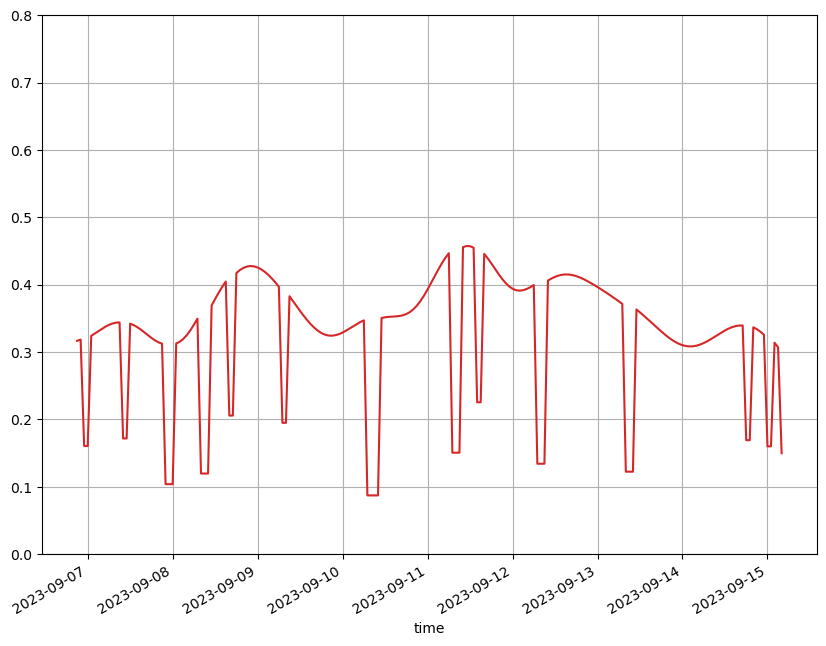

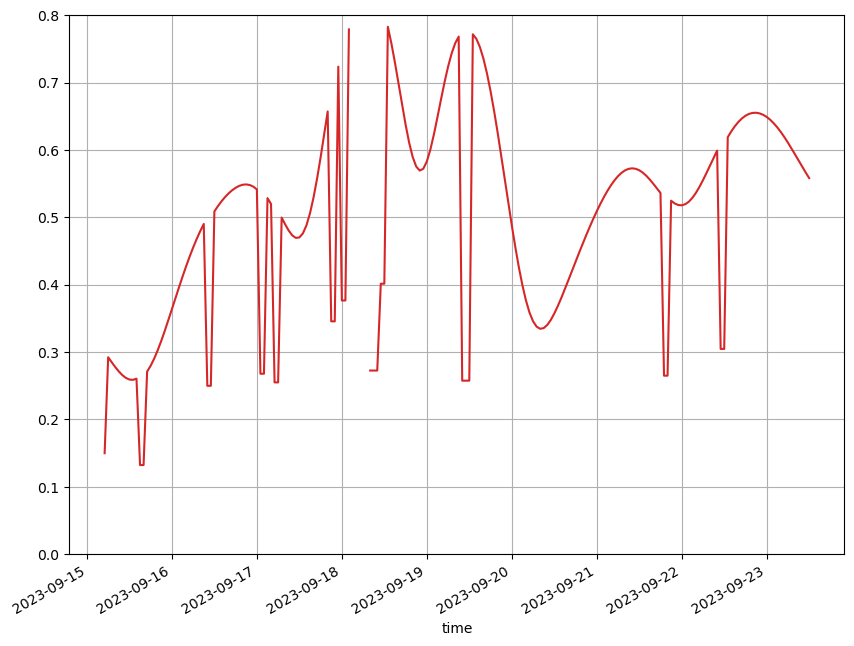

In [41]:
# to visualize data gaps:
for ii in range(0, int(np.floor(len(abs_vel_thres)/200.))):
    abs_vel_thres[(ii*200):((ii+1)*200)].plot(figsize=(10,7), c='C3')
    plt.ylim([0,0.8])
    plt.grid()

### 2.4.2. Smaller spike removal

We will use a moving threshold based on the standard deviation of the window. Values of speed outside this threshold will be marked as spikes

In [42]:
n_window = int(diff_time_thres / temp_res) #12 # we leave like this for now
n_window

3

In [43]:
# Number of points of the window
window_data = n_window

In [44]:
# Obtain the moving std
speed_std = abs_vel_thres.rolling(time=window_data, center=True).std()
speed_median = abs_vel_thres.rolling(time=window_data, center=True).median()
#speed_std = speed_median.rolling(time=int(window_data/2), center=True).std()

In [45]:
# Overview
import matplotlib.dates as mdates
dates = mdates.date2num(DS02['time'])
dates

array([19473.54166667, 19473.58333333, 19473.625     , ...,
       19625.375     , 19625.41666667, 19625.45833333])

In [46]:
speed_median.shape

(3647,)

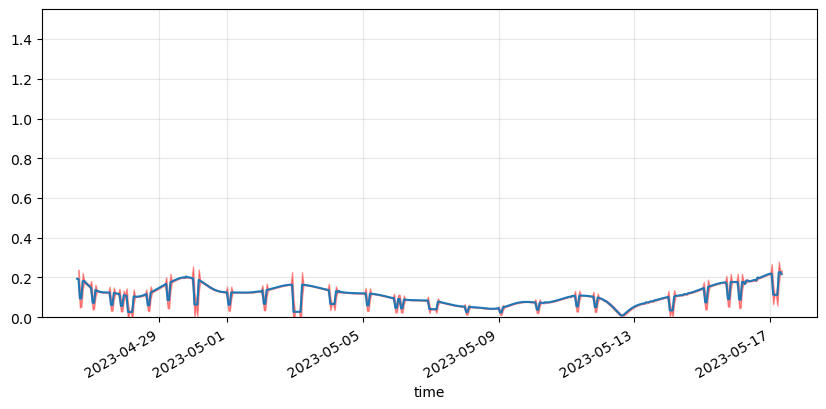

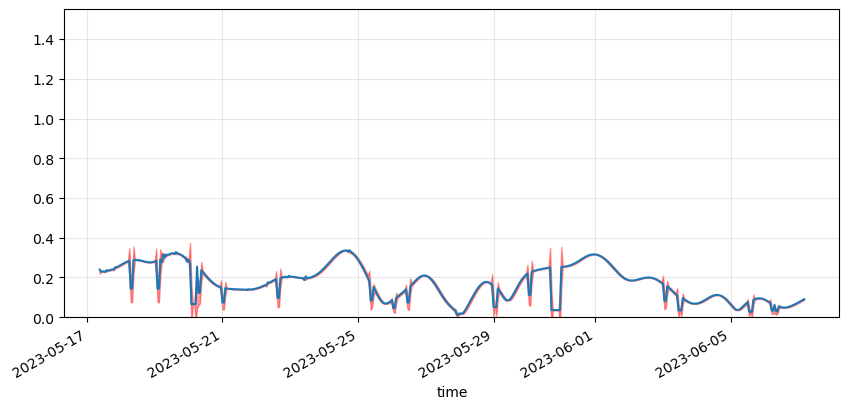

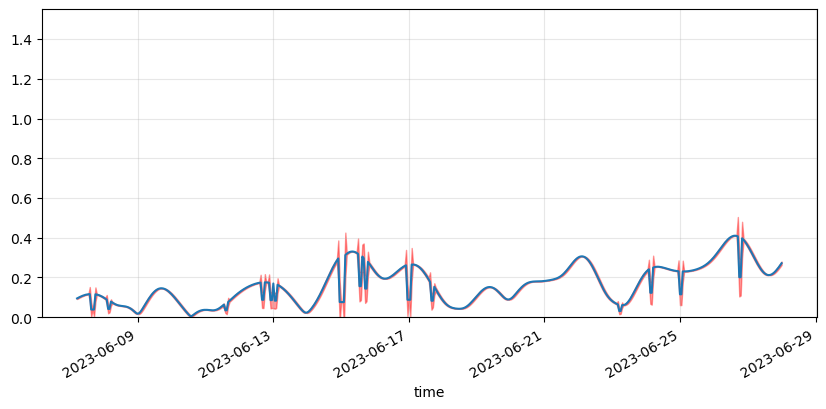

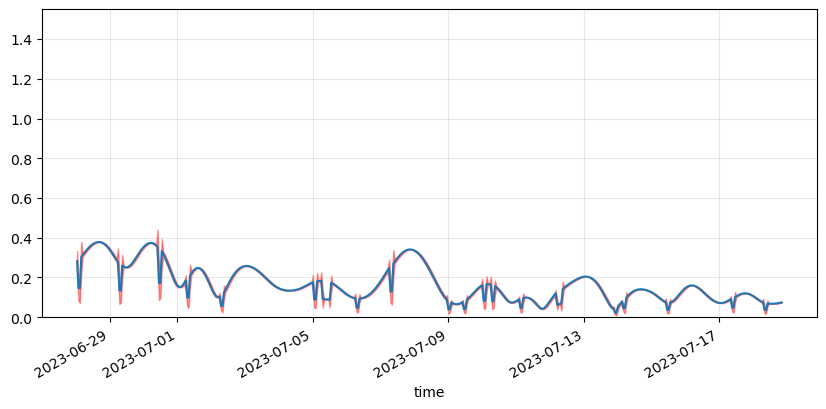

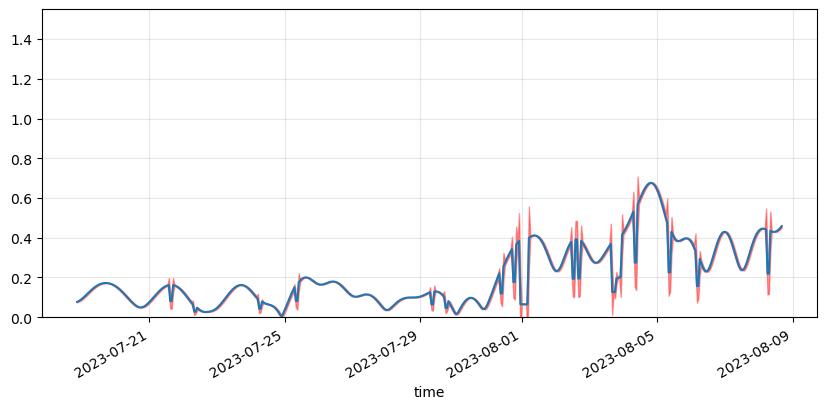

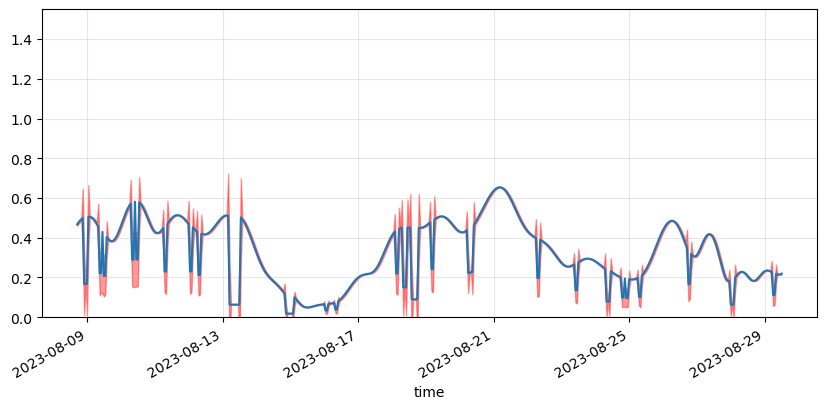

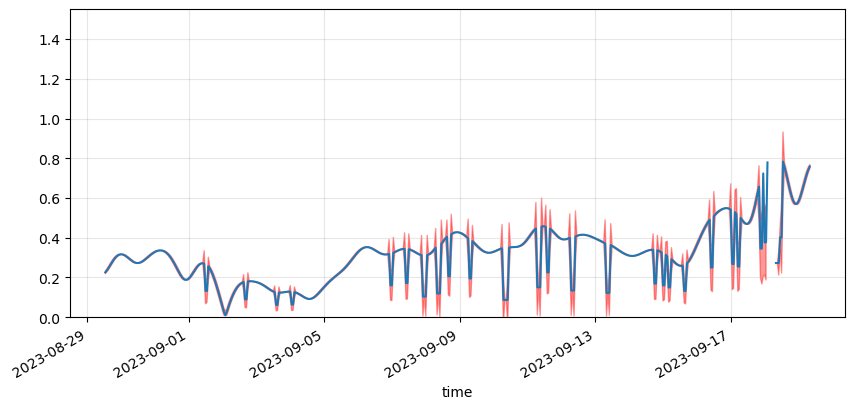

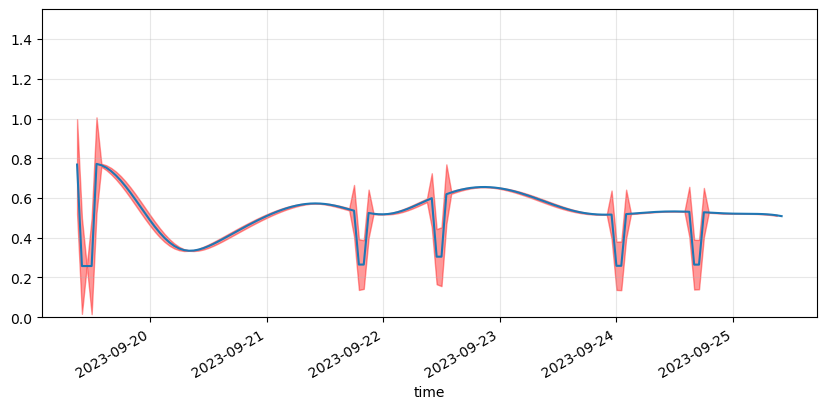

In [47]:
# Zoomed subsamples
tt = 500
for ii in range(0, int(np.ceil(len(abs_vel)/tt))):
    plt.figure(figsize=(10,4))
    x = dates[(ii*tt):((ii+1)*tt)]
    y = speed_median[(ii*tt):((ii+1)*tt)]
    std_zoom = speed_std[(ii*tt):((ii+1)*tt)]
    plt.fill_between(x=x, y1=y-std_zoom, y2=y+std_zoom,color='r',alpha=0.4)
    abs_vel_thres[(ii*tt):((ii+1)*tt)].plot()
    plt.ylim([0,1.55])
    plt.grid(alpha=0.3)

In [48]:
# Set limits for spike cleaning
upper_limit = speed_median + speed_std
bottom_limit = speed_median - speed_std

In [49]:
DS04 = DS03.where((abs_vel_thres < upper_limit) & (abs_vel_thres > bottom_limit))

Zonal component:

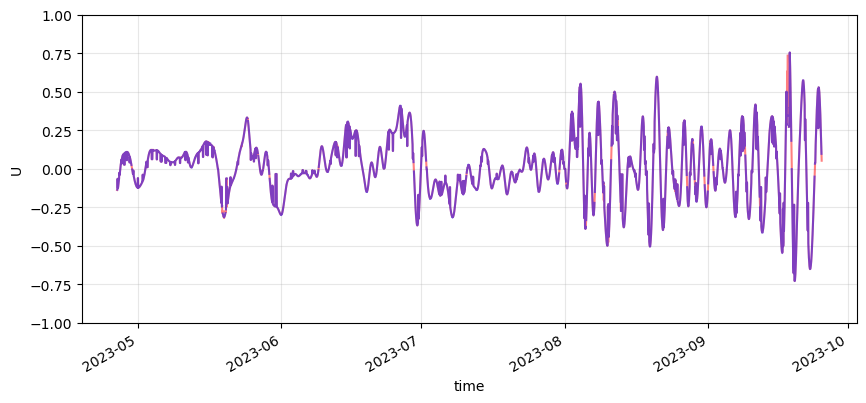

In [50]:
plt.figure(figsize=(10,4))
DS03.U.plot(alpha = 0.5, color = "red", label='old');
DS04.U.plot(alpha = 0.5, color = "blue", label='new');
plt.ylim(-1,1)
plt.grid(alpha=0.3)

Meridional component:

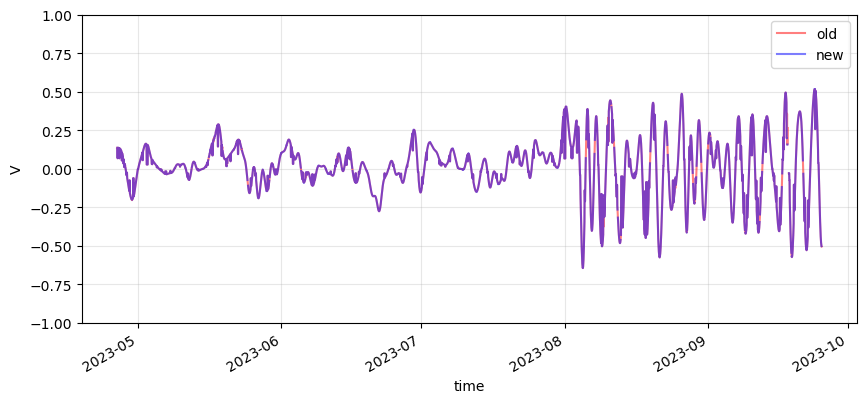

In [51]:
plt.figure(figsize=(10,4))
DS03.V.plot(alpha = 0.5, color = "red", label='old');
DS04.V.plot(alpha = 0.5, color = "blue", label='new');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

## 2.5. Smoothing

### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [52]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
#ds05 = ds04.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [53]:
DS05 = DS04.interpolate_na(dim='time', method="pchip") # Fill in NaNs by interpolating according to different methods.
# Pchip : cubic with splines interp. (Dani find ref.)

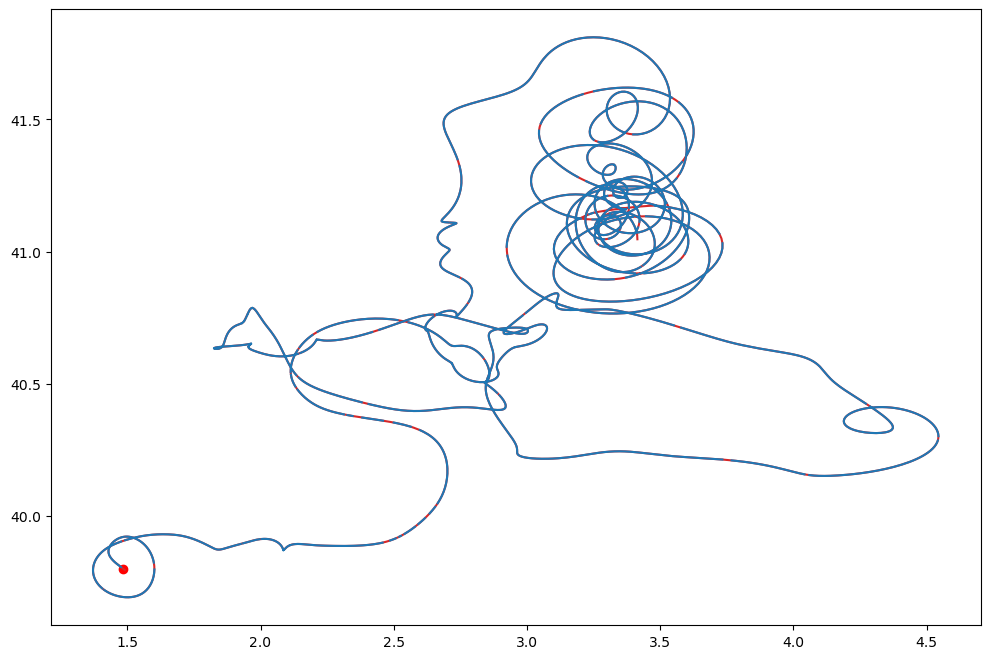

In [54]:
plt.figure(figsize=(12,8))
plt.plot(DS05.lon_filtered, DS05.lat_filtered, 'C3')
plt.plot(DS04.lon_filtered, DS04.lat_filtered)
plt.scatter(DS05.lon_filtered[1], DS05.lat_filtered[1], c='r')

/home/everger/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)


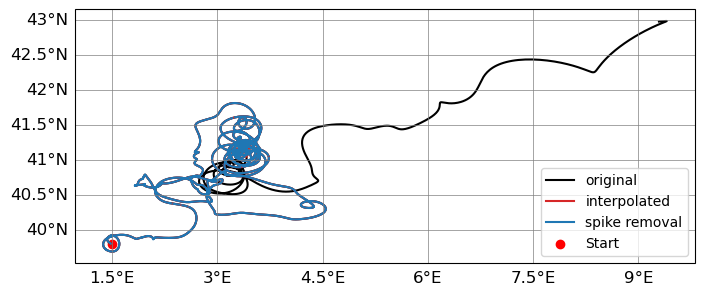

In [56]:
plt.figure(figsize=(8,8))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())
ax1.plot(DS00.lon_filtered, DS00.lat_filtered, 'k', label='original', transform=ccrs.PlateCarree())
ax1.plot(DS05.lon_filtered, DS05.lat_filtered, 'C3', label='interpolated', transform=ccrs.PlateCarree())
ax1.plot(DS04.lon_filtered, DS04.lat_filtered, label='spike removal', transform=ccrs.PlateCarree())
ax1.scatter(DS05.lon_filtered[0], DS05.lat_filtered[0], c='r', label='Start', transform=ccrs.PlateCarree())
plt.legend()

# #############
# # Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                               scale='10m', zorder=10,
#                                               edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 12}#, 'color': 'gray'}
gl.ylabel_style = {'size': 12}#, 'color': 'gray'}
#############

# ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0', zorder=50) 
# ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='End', zorder=51) 

# ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
# ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

###################

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# # --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

# plt.savefig(savedir_figs + 'traj_parts_' + outname + '.png', dpi=300)

# plt.show()

## Zooming in :

/home/everger/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:671: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)


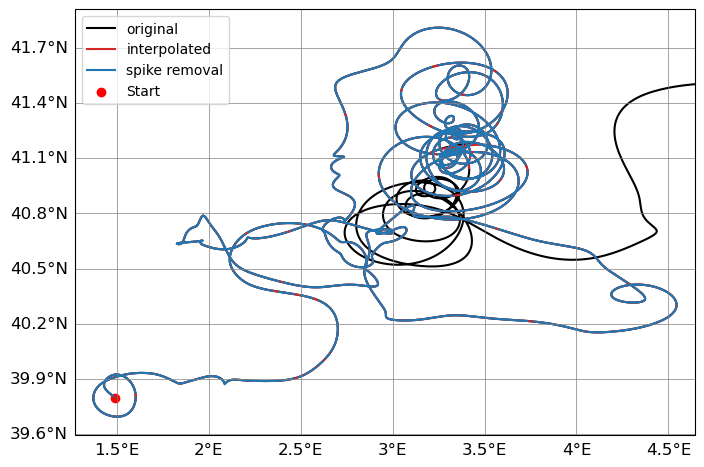

In [57]:
plt.figure(figsize=(8,8))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())
ax1.plot(DS00.lon_filtered, DS00.lat_filtered, 'k', label='original', transform=ccrs.PlateCarree()) # [0:-2900] used for previous plot on LON and LAT wo/ map_extent
ax1.plot(DS05.lon_filtered, DS05.lat_filtered, 'C3', label='interpolated', transform=ccrs.PlateCarree())
ax1.plot(DS04.lon_filtered, DS04.lat_filtered, label='spike removal', transform=ccrs.PlateCarree())
ax1.scatter(DS05.lon_filtered[0], DS05.lat_filtered[0], c='r', label='Start', transform=ccrs.PlateCarree())
plt.legend()

# #############
# # Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                               scale='10m', zorder=10,
#                                               edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 12}#, 'color': 'gray'}
gl.ylabel_style = {'size': 12}#, 'color': 'gray'}
#############

# ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0', zorder=50) 
# ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='End', zorder=51) 

thresa = .1
map_extent = [DS04.lon_filtered.min().values - thresa, DS04.lon_filtered.max().values + thresa
              , DS04.lat_filtered.min().values - thresa, DS04.lat_filtered.max().values + thresa]
ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
# ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

###################

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# # --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

# plt.savefig(savedir_figs + 'traj_parts_zoom' + outname + '.png', dpi=300)

# plt.show()


### 2.5.2. Applying smoothing
To remove small scale noise and any remaining spikes.

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

In [58]:
DS06 = DS05.copy()

Creating new variables with mirror boundary conditions 

(for testing on this see : http://localhost:8889/notebooks/code/drifters/processing/fast_swot_drifter_processing_rough02.ipynb)

In [59]:
nn = 100
lonb = DS05.lon_filtered.values
lona = np.flipud(DS05.lon_filtered.values[0:nn])
lonc = np.flipud(DS05.lon_filtered.values[-nn::])

latb = DS05.lat_filtered.values
lata = np.flipud(DS05.lat_filtered.values[0:nn])
latc = np.flipud(DS05.lat_filtered.values[-nn::])

In [60]:
lon_cat = np.concatenate((lona, lonb, lonc))
lat_cat = np.concatenate((lata, latb, latc))

Applying the window smoothing

In [61]:
window = signal.windows.hamming(n_window) # 6 hours (6 points) 

In [62]:
lon_win = signal.convolve(lon_cat, window, mode='same') / np.sum(window)
DS06["lon_filtered"][:] = lon_win[nn:-nn]

lat_win = signal.convolve(lat_cat, window, mode='same') / np.sum(window)
DS06["lat_filtered"][:] = lat_win[nn:-nn]

In [63]:
DS06

<xarray.Dataset>
Dimensions:       (time: 3647)
Coordinates:
  * time          (time) datetime64[ns] 2023-04-26T13:00:00 ... 2023-09-25T11...
Data variables:
    LAT           (time) float64 39.8 39.8 39.8 39.79 ... 41.09 41.08 41.07
    LON           (time) float64 1.485 1.484 1.479 1.471 ... 3.425 3.434 3.442
    sst           (time) float64 18.61 19.54 19.73 19.51 ... 25.08 25.11 25.16
    slp           (time) float64 1.015e+03 1.016e+03 ... 1.038e+03 1.036e+03
    lon_filtered  (time) float64 1.49 1.484 1.477 1.471 ... 3.41 3.414 3.415
    lat_filtered  (time) float64 39.8 39.8 39.81 39.81 ... 41.08 41.06 41.05
    U             (time) float64 -0.06662 -0.2077 -0.1372 ... 0.05029 0.004781
    V             (time) float64 0.06696 0.2016 0.1343 ... -0.5048 -0.4951

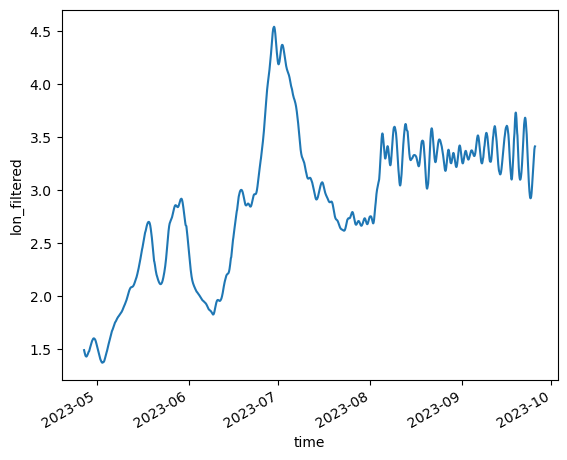

In [64]:
DS06.lon_filtered.plot()

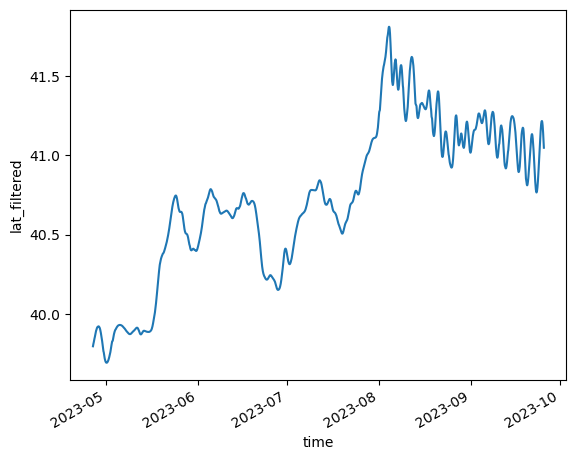

In [65]:
DS06.lat_filtered.plot()

## 2.6. Recalculate U and V:

In [66]:
_, ufor, vfor    = latlon2uv_dir(DS06['lat_filtered'], DS06['lon_filtered'], temp_res, 'for') # 600 = temporal resolution
_, uback, vback  = latlon2uv_dir(DS06['lat_filtered'], DS06['lon_filtered'], temp_res, 'back')

In [67]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

In [68]:
DS = DS06.copy()

In [69]:
# Add variables to the dataset
DS = DS.assign(U=(ufor+uback)*0.5)
DS = DS.assign(V=(vfor+vback)*0.5)
# ds06 = ds06.assign(UV=(uvabsfor+uvabsback)*0.5)
print(list(DS.keys()))

['LAT', 'LON', 'sst', 'slp', 'lon_filtered', 'lat_filtered', 'U', 'V']


# Comparing abs. vel before and after smoothing:

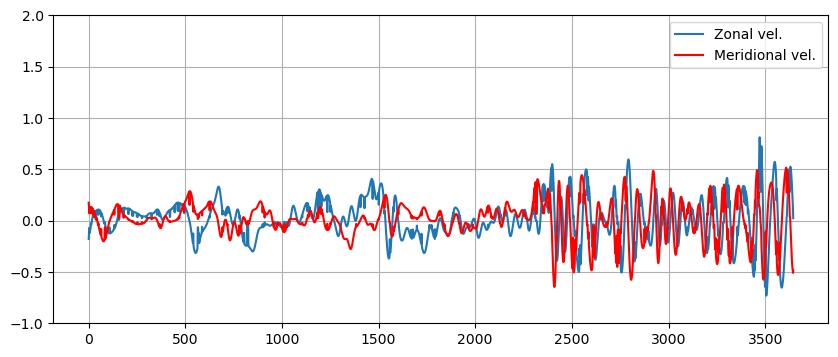

In [70]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
plt.plot(u, label='Zonal vel.')
plt.plot(v, 'r', label='Meridional vel.')
plt.ylim(-1,2)
plt.legend()
plt.grid()

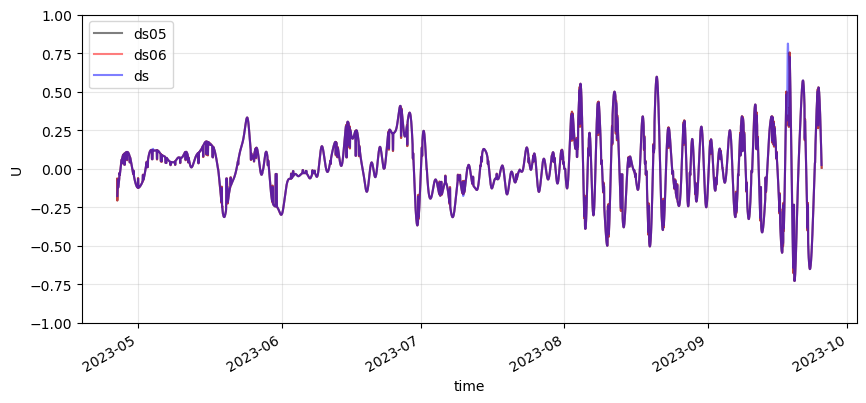

In [73]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
DS05.U.plot(alpha = 0.5, color = "k", label='ds05');
DS06.U.plot(alpha = 0.5, color = "r", label='ds06');
DS.U.plot(alpha = 0.5, color = "b", label='ds');
plt.ylim(-1, 1)
plt.grid(alpha=0.3)
plt.legend()

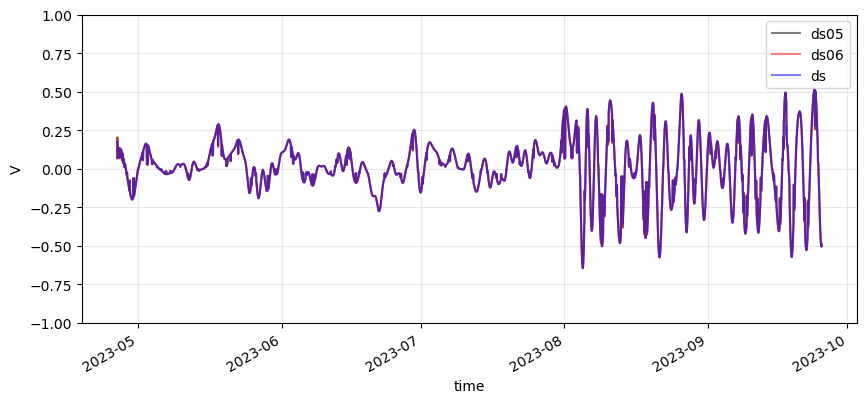

In [74]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
DS05.V.plot(alpha = 0.5, color = "k", label='ds05');
DS06.V.plot(alpha = 0.5, color = "r", label='ds06');
DS.V.plot(alpha = 0.5, color = "b", label='ds');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later

# 3. Saving data

In [75]:
# rootdir = '../../../../../'

In [76]:
# outdir = 'data/drifters/L1_IMEDEA/'

In [77]:
# #  Renaming as no longer using SOCIB's L0
# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# # --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]


## Copying attributes of SOCIB dataset to this one:

In [78]:
# ds.attrs = ds_url.attrs

## Saving to netcdf:

In [79]:
# savefile = rootdir + outdir + outname + '.nc'

### Checking first if ile already exists:

In [80]:
# if os.path.exists(savefile):
#     # Replace the file or do whatever operation you need
#     os.remove(savefile)  # Delete the existing file, if you want to replace it completely
#     # Here you can create a new file or copy a template file, etc.
#     print(f"{savefile} exists and has been replaced.")
# else:
#     print(f"{savefile} does not exist.")

### Saving:

In [81]:
# ds.to_netcdf(savefile)

In [82]:
# !ls ../../../../../data/drifters/L1_IMEDEA/

# 4. Plotting outputs

In [90]:
map_extent=[-0.3, 5, 38.5, 42]
fsize=14

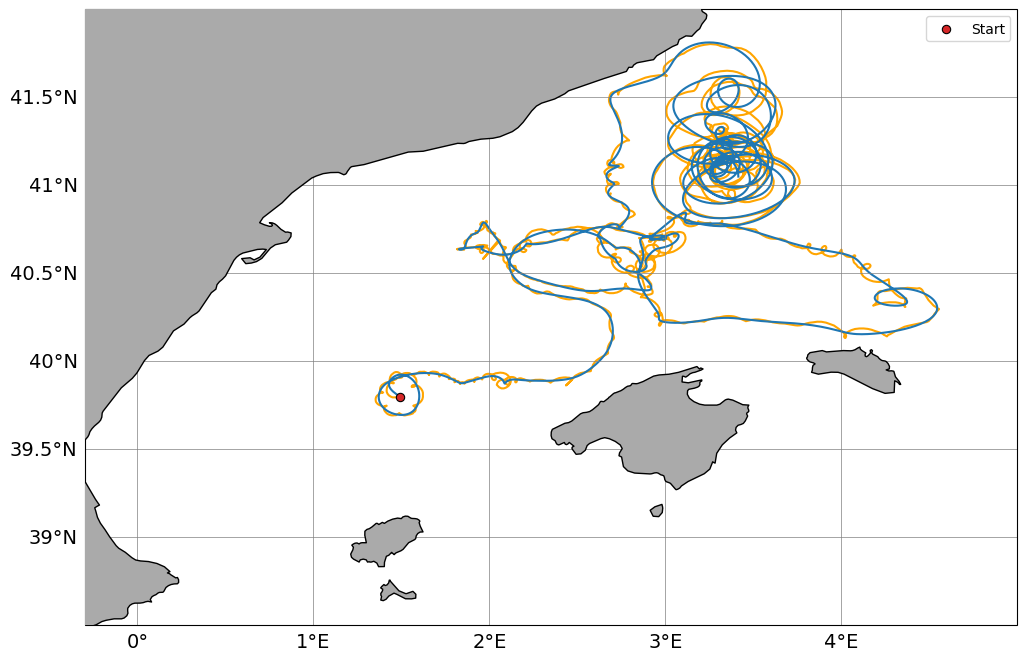

In [91]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(DS.LON, DS.LAT, transform=ccrs.PlateCarree(),c='ORANGE') #afegit per elisabet per veure diferència amb filtrat

ax1.plot(DS.lon_filtered, DS.lat_filtered, transform=ccrs.PlateCarree(), c='C0') 
ax1.scatter(DS.lon_filtered[0], DS.lat_filtered[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# # --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

# plt.savefig(savedir_figs + 'traj_proc_' + outname + '.png', dpi=300)

plt.show()

## Velocity:

In [92]:
thresa = .1
map_extent = [DS.lon_filtered.min().values - thresa, DS.lon_filtered.max().values + thresa, DS.lat_filtered.min().values - thresa, DS.lat_filtered.max().values + thresa]

In [93]:
abs_vel = (DS.U**2 + DS.V**2)**0.5

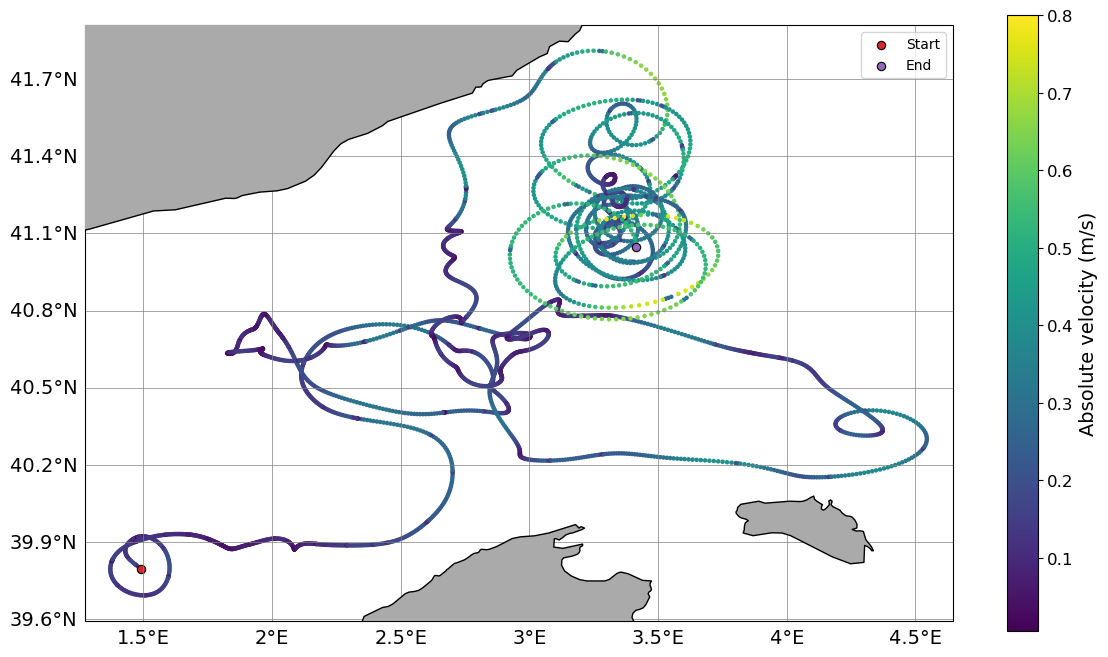

In [98]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

cc = ax1.scatter(DS.lon_filtered, DS.lat_filtered, s=5, c=abs_vel, vmax=0.8, transform=ccrs.PlateCarree())
ax1.scatter(DS.lon_filtered[0], DS.lat_filtered[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree()
            , label='Start')
ax1.scatter(DS.lon_filtered[-1], DS.lat_filtered[-1], c='C4', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree()
            , label='End')
cbar = plt.colorbar(cc)
cbar_label = r'Absolute velocity (m/s)'
cbar.ax.tick_params(labelsize=fsize-2)
cbar.ax.set_ylabel(cbar_label, fontsize=fsize)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title(ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# # --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

# plt.savefig(savedir_figs + 'traj_proc_vels_' + outname + '.png', dpi=300)

# plt.show()